실습6. 평균과 변동성 밴드 함께 그리기
- 이동평균선에 표준편차 두 배 띠를 둘러 정상 범위 보기

목표
- 이동평균선에 표준편차 두 배 띠를 둘러 정상 범위를 시각화

단계
- 창 크기 20으로 이동평균과 이동표준편차를 구하기
- 원본과 이동평균을 그리기
- 평균에 표준편차 두 배를 더하고 뺀 띠를 색으로 채우기

예상 결과
- 이동평균 주위로 폭이 변하는 정상 범위 띠

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/21_cmapss_fd001_sample.csv")

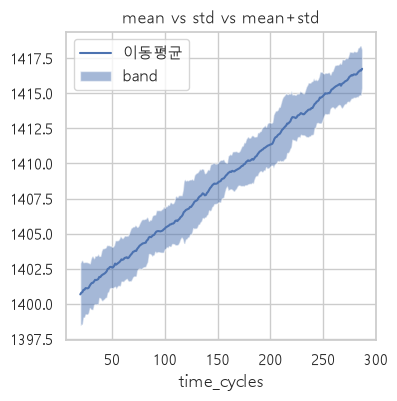

In [12]:
eng_02 = df[df["unit_nr"] == 2]

# 이동평균
ma = eng_02["s_4"].rolling(window=20).mean()

# 이동표준편차
std = eng_02["s_4"].rolling(window=20).std()

plt.figure(figsize=(4, 4))
plt.title("mean vs std vs mean+std")

# plt.plot(eng_02["time_cycles"], eng_02["s_4"], label="원본")
plt.plot(eng_02["time_cycles"], ma, label="이동평균")
# plt.plot(eng_02["time_cycles"], std, label="이동표준편차")

top = ma + 2 * std
bottom = ma - 2 * std

plt.fill_between(eng_02["time_cycles"], bottom, top, alpha=0.5, label='band')

plt.legend()
plt.xlabel("time_cycles")
plt.show()
